In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
file_path = os.path.expanduser("~/Documents/Research/diagnosis_data.csv")
chunk_size = 10000
n_rows = 500000

data_list = []
chunks_processed = 0

In [5]:
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    chunk = chunk[(chunk['Total Cost'] >= 0) & (chunk['Age'] >= 0) & (chunk['ZIP'] >= 0)& (chunk['NCHS'] >= 0)& (chunk['Pay1'] >= 0)]
    data_list.append(chunk)
    chunks_processed += len(chunk)
    if chunks_processed >= n_rows:
        break

data = pd.concat(data_list, ignore_index=True)

In [6]:
for col in ['Total Cost', 'Age']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    data = data[(data[col] >= (Q1 - 1.5 * IQR)) & (data[col] <= (Q3 + 1.5 * IQR))]

In [7]:
features = ['Age', 'Female', 'Diagnosis', 'ZIP', 'NCHS', 'Pay1']
X = data[features]
y = data['Total Cost']

In [8]:
X = pd.concat([X.drop('Diagnosis', axis=1), pd.get_dummies(X['Diagnosis'], prefix='Diag', drop_first=True)], axis=1)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6)
model.fit(X_train, y_train)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1445.14
Mean Squared Error (MSE): 3783790.95
Root Mean Squared Error (RMSE): 1945.20
R² Score: 0.2804


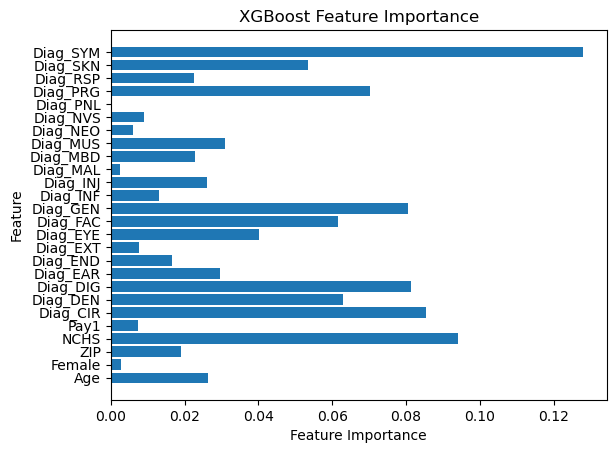

In [12]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Get feature importances
feature_importances = model.feature_importances_

# Plot feature importances
plt.barh(X.columns, feature_importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.show()
